Mini-project: adoptable dog predictor - random forest edition

We will use the same dataset as the decision tree notebook so that we can compare a single decision tree to a random forest.

But to make this project even more fun, we will add a cute score~

In [19]:
import numpy as np
import pandas as pd

np.random.seed(42)

m = 200

age = np.random.randint(0, 15, size=m)
size = np.random.choice([0,1,2], size=m)
energy_level = np.random.choice([1,2,3,4,5], size=m)
good_with_kids = np.random.choice([0,1], size=m)
trained = np.random.choice([0,1], size=m)
cute_score = np.random.randint(1, 11, size=m)

X = pd.DataFrame({
    "age": age,
    "size": size,
    "energy_level": energy_level,
    "good_with_kids": good_with_kids,
    "trained": trained,
    "cute_score": cute_score
})

X.head()

,age,size,energy_level,good_with_kids,trained,cute_score
0,6,0,4,0,1,10
1,3,2,1,1,0,2
2,12,2,4,1,0,1
3,14,0,5,0,1,10
4,10,2,5,0,1,9


In [20]:
score = (
    (age < 5)*2 +
    good_with_kids*2 +
    trained*2 +
    (energy_level >= 4)*1 +
    (cute_score >= 7)*1
)

y = (score >= 4).astype(int)

# add randomness
np.random.seed(42)
noise = np.random.rand(m) < 0.1
y = np.where(noise, 1 - y, y)

data = X.copy()
data["adopted_fast"] = y
data.head()

,age,size,energy_level,good_with_kids,trained,cute_score,adopted_fast
0,6,0,4,0,1,10,1
1,3,2,1,1,0,2,1
2,12,2,4,1,0,1,0
3,14,0,5,0,1,10,1
4,10,2,5,0,1,9,1


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Build a single decision tree:

From the decision tree notebook, we noticed that depth = 5 was the giving the best results.

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)

tree_train_acc = accuracy_score(y_train, tree.predict(X_train))
tree_val_acc = accuracy_score(y_val, tree.predict(X_val))

Note: the slight differences in accuracy are due to the new feature we added (cute_score). If we remove that feature and keep the exact same dataset as in the decision tree notebook, we will get the same accuracy values.

Build a Random Forest:

In [23]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
forest.fit(X_train, y_train)

forest_train_acc = accuracy_score(y_train, forest.predict(X_train))
forest_val_acc = accuracy_score(y_val, forest.predict(X_val))

Compare the accuracies:

In [25]:
print('Single decision tree training accuracy: ',tree_train_acc)
print('Single decision tree validation accuracy: ',tree_val_acc)

print('Random forest training accuracy: ',forest_train_acc)
print('Random forest validation accuracy: ',forest_val_acc)

Single decision tree training accuracy:  0.9428571428571428
Single decision tree validation accuracy:  0.7166666666666667
Random forest training accuracy:  0.9285714285714286
Random forest validation accuracy:  0.7833333333333333


Now let's compare the variance:

We will train many models with different random seeds, and compare the validation accuracy.

In [26]:
tree_scores = []

for seed in range(30):
    tree = DecisionTreeClassifier(max_depth=5, random_state=seed)
    tree.fit(X_train, y_train)
    score = accuracy_score(y_val, tree.predict(X_val))
    tree_scores.append(score)

In [27]:
forest_scores = []

for seed in range(30):
    forest = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=seed
    )
    forest.fit(X_train, y_train)
    score = accuracy_score(y_val, forest.predict(X_val))
    forest_scores.append(score)

In [30]:
print('mean std')
print('Decision trees:', np.mean(tree_scores), np.std(tree_scores))
print('Random forests:', np.mean(forest_scores), np.std(forest_scores))

mean std
Decision trees: 0.701111111111111 0.026152449546532924
Random forests: 0.788888888888889 0.019404721329525528


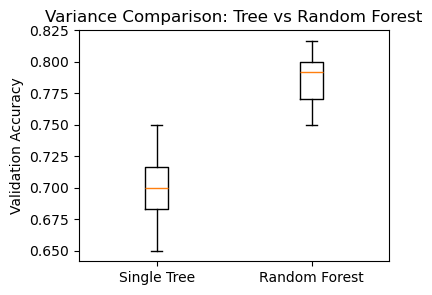

In [34]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1,1,figsize=(4,3))
ax.boxplot([tree_scores, forest_scores], tick_labels=["Single Tree", "Random Forest"])
ax.set_ylabel("Validation Accuracy")
ax.set_title("Variance Comparison: Tree vs Random Forest")
plt.show()

Conclusions: 

A single decision tree has high variance: small changes in the training data can produce very different trees and therefore different predictions.
Random forests reduce this variance by averaging the predictions of many trees trained on bootstrapped datasets and random feature subsets.
As a result, the random forest achieves higher validation accuracy and more stable performance across random seeds.

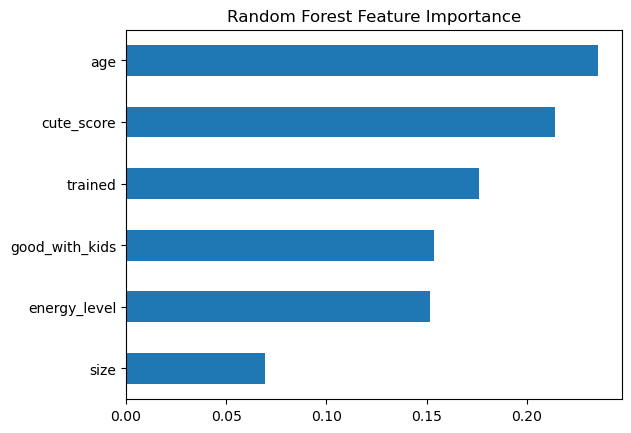

In [36]:
import pandas as pd

importance = pd.Series(forest.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.show()

Random forest feature importance measures how much each feature reduces impurity across all trees in the forest. Features that frequently create good splits receive higher importance.

In this dataset, age and cute_score are the most influential predictors for whether a dog is adopted quickly!

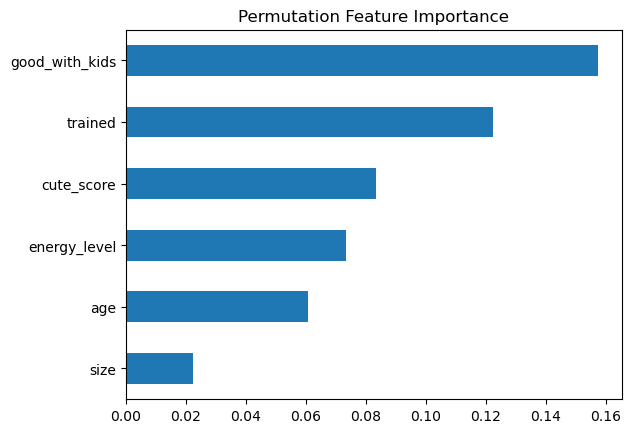

In [37]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(forest, X_val, y_val, n_repeats=20, random_state=42)

importance = pd.Series(perm.importances_mean, index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Permutation Feature Importance")
plt.show()

Random forest feature importance measures how frequently a feature is used to reduce impurity in the trees. Permutation importance instead measures the drop in model performance when the feature is randomly shuffled. Because these methods measure different quantities, the feature rankings can differ.

Last experiment: 

We will train forests with different numbers of trees. It should make variance reduction quite obvious~

Let's try with: 1, 5, 10, 20, 50, 100 trees.

In [39]:
n_trees_list = [1, 5, 10, 20, 50, 100]

means = []
stds = []

for n_trees in n_trees_list:
    
    scores = []
    
    for seed in range(30):
        
        forest = RandomForestClassifier(
            n_estimators=n_trees,
            max_depth=5,
            random_state=seed
        )
        
        forest.fit(X_train, y_train)
        pred = forest.predict(X_val)
        scores.append(accuracy_score(y_val, pred))
    
    means.append(np.mean(scores))
    stds.append(np.std(scores))

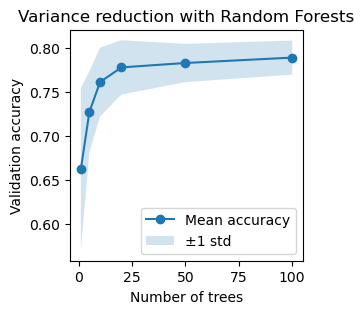

In [40]:
f, ax = plt.subplots(1,1,figsize=(3,3))

ax.plot(n_trees_list, means, marker="o", label="Mean accuracy")
ax.fill_between(
    n_trees_list,
    np.array(means) - np.array(stds),
    np.array(means) + np.array(stds),
    alpha=0.2,
    label="±1 std"
)

ax.set_xlabel("Number of trees")
ax.set_ylabel("Validation accuracy")
ax.set_title("Variance reduction with Random Forests")
plt.legend()
plt.show()

We get what we expect:
- few trees: high variance
- many trees: lower variance, because averaging many models stabilizes the model and improves generalization